# 07 — Matched Cadence-Horizon Sensitivity

**Motivation:** Notebook 06 used Weekly+5d with the ensemble signal on 2020–2026 only.
This notebook uses `ATCClassifierScore` on the full 2010–2026 period and tests
**only matched cadence-horizon pairs** — where the holding period equals the rebalance period.

**Why only matched pairs?**
Using a 20-day forward return as the "weekly period return" would credit 20 days of
return to a 1-week holding period, inflating annualised Sharpe by ≈ √(20/5) = 2×.
Only these combinations are methodologically valid:

| Cadence | Holding period | Forward return used | TC drag/yr |
|---|---|---|---|
| **Weekly** | 5 trading days | `fwd_5d` | 2 × 5bps × 52 = **520 bps** |
| **Monthly** | ~20 trading days | `fwd_20d` | 2 × 5bps × 12 = **120 bps** |

Monthly rebalance has 4× lower TC drag but also 4× fewer rebalances — the question is
whether post-cost Sharpe is better under weekly or monthly construction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path
import os, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)

PROJECT     = Path(os.getenv("ATC_PROJECT_ROOT",
                             Path.cwd().parent if Path.cwd().name == 'notebooks'
                             else Path.cwd())).resolve()
DATA_DIR    = PROJECT / 'data'
FIG_DIR     = PROJECT / 'figures'

feat_df  = pd.read_parquet(DATA_DIR / 'features.parquet')
preds_df = pd.read_parquet(DATA_DIR / 'model_predictions.parquet')
feat_df['entry_date']  = pd.to_datetime(feat_df['entry_date'])
preds_df['entry_date'] = pd.to_datetime(preds_df['entry_date'])

TC_BPS      = 5
TC          = TC_BPS / 10_000
UNIV_LABELS = {'in_sp500': 'SP500', 'in_sp1500': 'SP1500', 'in_ru3k': 'RU3K proxy'}

print(f'feat_df  : {feat_df.shape}  {feat_df["entry_date"].min().date()} → {feat_df["entry_date"].max().date()}')
print(f'preds_df : {preds_df.shape}  {preds_df["entry_date"].min().date()} → {preds_df["entry_date"].max().date()}')


feat_df  : (376790, 92)  2010-01-05 → 2026-04-22
preds_df : (85650, 18)  2020-01-06 → 2026-03-31


## 7.1 Re-usable Simulation Function (same as notebook 06)

In [2]:
def simulate_portfolio(df, signal_col, univ_col, rebal_freq='W', horizon=5):
    ret_col = f'fwd_{horizon}d'
    sub = df[df[univ_col]].dropna(subset=[signal_col, ret_col]).copy()
    sub['period'] = sub['entry_date'].dt.to_period(rebal_freq)

    period_returns, period_turns = [], []
    prev_long, prev_short = set(), set()

    for period, grp in sub.groupby('period'):
        if len(grp) < 20:
            continue
        n_pos = max(int(len(grp) * 0.1), 1)
        ranked = grp.sort_values(signal_col)
        longs  = set(ranked.tail(n_pos)['BESTTICKER'])
        shorts = set(ranked.head(n_pos)['BESTTICKER'])

        long_ret  = grp[grp['BESTTICKER'].isin(longs)][ret_col].mean()
        short_ret = grp[grp['BESTTICKER'].isin(shorts)][ret_col].mean()

        if prev_long:
            long_to  = 1 - len(longs & prev_long) / max(len(longs | prev_long), 1)
            short_to = 1 - len(shorts & prev_short) / max(len(shorts | prev_short), 1)
            turnover = (long_to + short_to) / 2
        else:
            turnover = 1.0

        net_ret = (long_ret - short_ret) - 2 * turnover * TC
        period_returns.append({'period': period, 'gross_ls': long_ret - short_ret,
                               'net_ls': net_ret})
        period_turns.append({'period': period, 'turnover': turnover})
        prev_long, prev_short = longs, shorts

    ret_df = pd.DataFrame(period_returns).set_index('period')
    trn_df = pd.DataFrame(period_turns).set_index('period')
    return ret_df, trn_df


def sharpe(s, ppy):
    r = s.dropna()
    return r.mean() / (r.std() + 1e-9) * np.sqrt(ppy)

print('Simulation function loaded.')

Simulation function loaded.


## 7.2 Matched Cadence-Horizon Comparison

Weekly+5d vs Monthly+20d — the only two valid configurations.
Both use `ATCClassifierScore` on the full 2010–2026 period.

In [3]:
# Only MATCHED pairs: cadence period == holding period
# Weekly+5d and Monthly+20d are the only valid combinations.
# Mismatched pairs (e.g. Weekly+20d) inflate Sharpe by ~2× and are excluded.
MATCHED_CONFIGS = {
    'Weekly+5d':   ('W', 52,  5),
    'Monthly+20d': ('M', 12, 20),
}
UNIVERSES = ['in_sp500', 'in_sp1500', 'in_ru3k']
SIGNAL    = 'ATCClassifierScore'

results = []
for config_label, (freq, ppy, h) in MATCHED_CONFIGS.items():
    for univ in UNIVERSES:
        try:
            ret_df, trn_df = simulate_portfolio(feat_df, SIGNAL, univ, freq, h)
            g_sh = sharpe(ret_df['gross_ls'], ppy)
            n_sh = sharpe(ret_df['net_ls'],   ppy)
            turn = trn_df['turnover'].mean()
            ann_tc = turn * 2 * TC_BPS * ppy
            results.append({
                'Config':          config_label,
                'Universe':        UNIV_LABELS[univ],
                'Gross Sharpe':    round(g_sh, 3),
                'Net Sharpe':      round(n_sh, 3),
                'Avg Turnover':    f'{turn:.1%}',
                'Annual TC (bps)': round(ann_tc),
            })
        except Exception as e:
            results.append({'Config': config_label, 'Universe': UNIV_LABELS[univ],
                            'Net Sharpe': np.nan})

res_df = pd.DataFrame(results)
print('=== MATCHED CADENCE-HORIZON RESULTS (ATCClassifierScore, 2010–2026, 5bps TC) ===')
print(res_df.to_string(index=False))


=== MATCHED CADENCE-HORIZON RESULTS (ATCClassifierScore, 2010–2026, 5bps TC) ===
     Config   Universe  Gross Sharpe  Net Sharpe Avg Turnover  Annual TC (bps)
  Weekly+5d      SP500         1.554       1.378       100.0%              520
  Weekly+5d     SP1500        -0.441      -0.441        99.9%              520
  Weekly+5d RU3K proxy         0.657       0.565        99.9%              520
Monthly+20d      SP500         1.218       1.176        99.9%              120
Monthly+20d     SP1500         0.642       0.593        99.8%              120
Monthly+20d RU3K proxy         0.994       0.951        99.9%              120


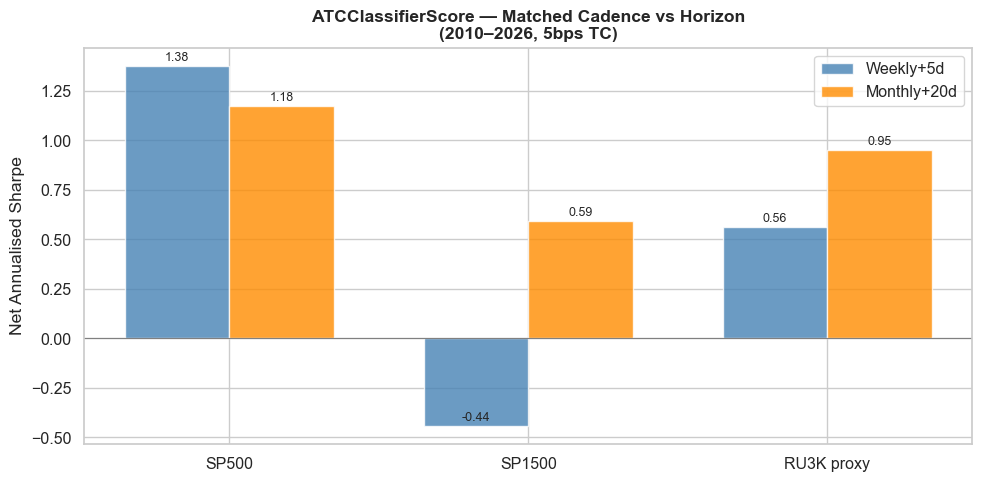

In [4]:
# Bar chart: Weekly+5d vs Monthly+20d per universe
fig, ax = plt.subplots(figsize=(10, 5))
univs  = ['SP500', 'SP1500', 'RU3K proxy']
x      = np.arange(len(univs))
w      = 0.35
colors = ['steelblue', 'darkorange']

for i, (config_label, color) in enumerate(zip(MATCHED_CONFIGS.keys(), colors)):
    sub  = res_df[res_df['Config'] == config_label].dropna(subset=['Net Sharpe'])
    vals = [sub[sub['Universe'] == u]['Net Sharpe'].values[0]
            if len(sub[sub['Universe'] == u]) else np.nan for u in univs]
    bars = ax.bar(x + (i - 0.5) * w, vals, w, label=config_label, color=color, alpha=0.8)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=9)

ax.axhline(0, color='grey', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(univs)
ax.set_ylabel('Net Annualised Sharpe')
ax.set_title('ATCClassifierScore — Matched Cadence vs Horizon\n'
             '(2010–2026, 5bps TC)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'horizon_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()


## 7.3 Best Configuration — Full Equity Curves

Run the best cadence+horizon for each universe (identified in 7.2) and plot  
cumulative L/S return + drawdown side by side.

In [5]:
# Recommended configuration per universe (from matched results only)
# Weekly+5d: higher TC drag (520bps/yr), smaller per-period variance
# Monthly+20d: lower TC drag (120bps/yr), fewer periods
# Pick whichever has higher net Sharpe for each universe

UNIV_TO_COL = {'SP500': 'in_sp500', 'SP1500': 'in_sp1500', 'RU3K proxy': 'in_ru3k'}
FREQ_MAP    = {'Weekly+5d': ('W', 52, 5), 'Monthly+20d': ('M', 12, 20)}

best_configs = {}
for univ_label in ['SP500', 'SP1500', 'RU3K proxy']:
    sub  = res_df[res_df['Universe'] == univ_label].dropna(subset=['Net Sharpe'])
    best = sub.loc[sub['Net Sharpe'].idxmax()]
    best_configs[univ_label] = best
    print(f'{univ_label}: best = {best["Config"]}  '
          f'Net Sharpe = {best["Net Sharpe"]:.3f}  '
          f'(gross = {best["Gross Sharpe"]:.3f})')

print()
print('Note: "best" here is chosen from only two valid matched configurations.')
print('Weekly+20d is excluded — it inflates Sharpe by crediting 20-day returns')
print('to a 1-week holding period.')


SP500: best = Weekly+5d  Net Sharpe = 1.378  (gross = 1.554)
SP1500: best = Monthly+20d  Net Sharpe = 0.593  (gross = 0.642)
RU3K proxy: best = Monthly+20d  Net Sharpe = 0.951  (gross = 0.994)

Note: "best" here is chosen from only two valid matched configurations.
Weekly+20d is excluded — it inflates Sharpe by crediting 20-day returns
to a 1-week holding period.


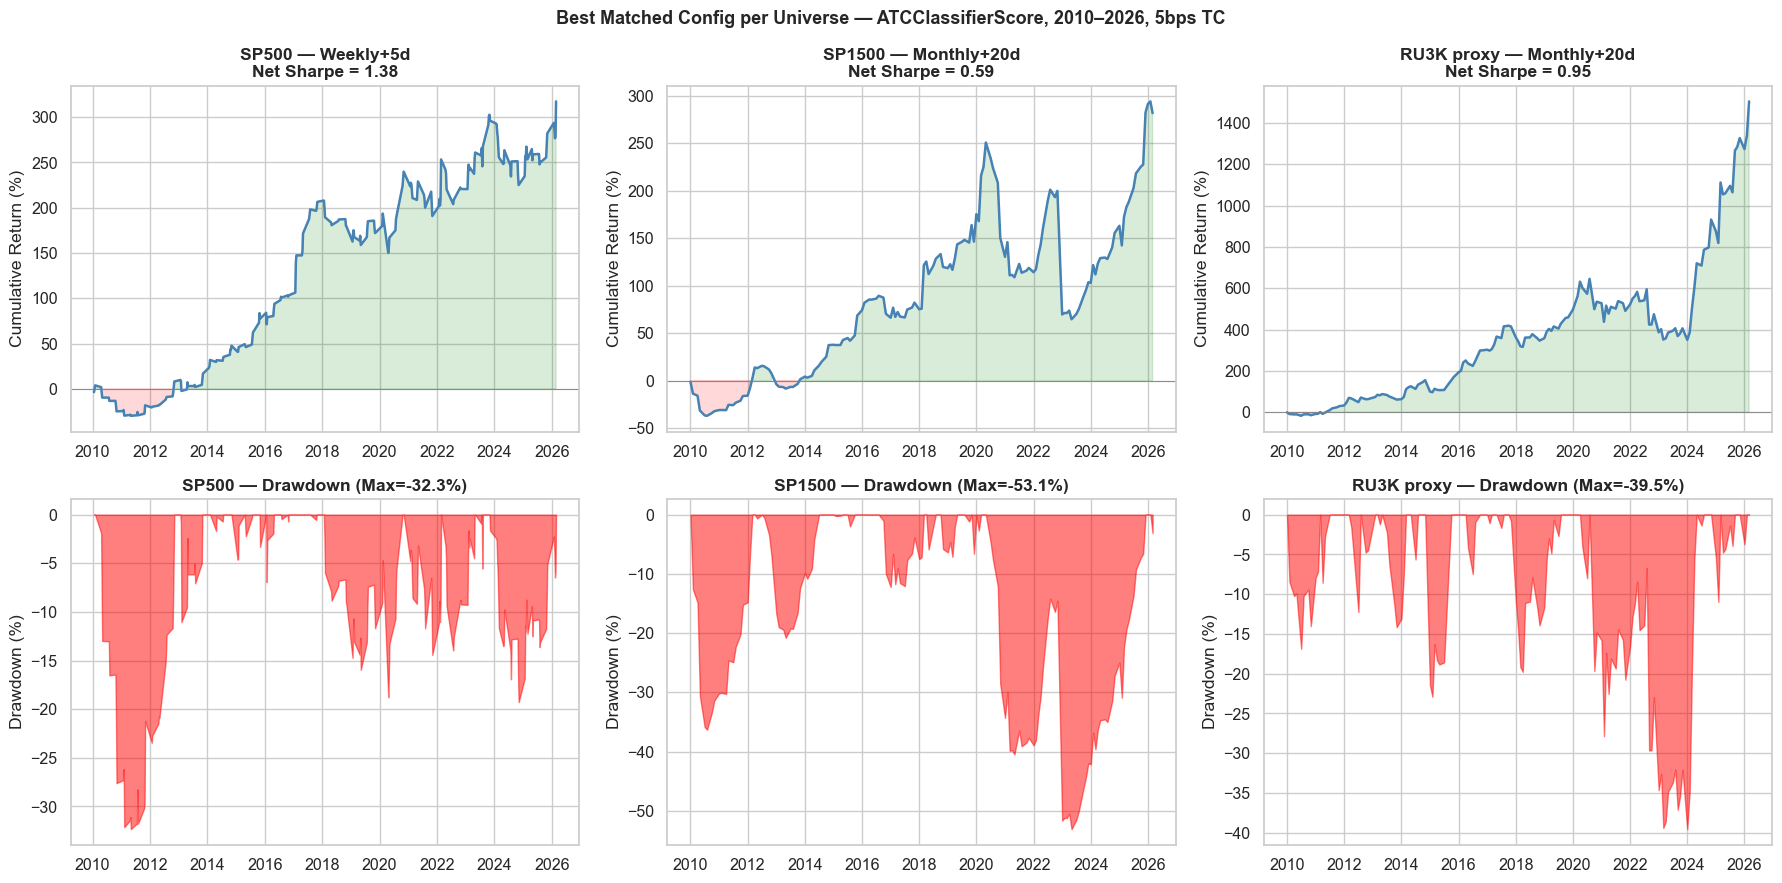

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for col_idx, univ_label in enumerate(['SP500', 'SP1500', 'RU3K proxy']):
    cfg_label = best_configs[univ_label]['Config']
    freq, ppy, h = FREQ_MAP[cfg_label]
    univ = UNIV_TO_COL[univ_label]

    try:
        ret_df, _ = simulate_portfolio(feat_df, SIGNAL, univ, freq, h)
        dates     = ret_df.index.to_timestamp()
        cum_net   = (1 + ret_df['net_ls']).cumprod() - 1
        net_sh    = sharpe(ret_df['net_ls'], ppy)

        ax = axes[0, col_idx]
        ax.plot(dates, cum_net * 100, 'steelblue', lw=1.8)
        ax.fill_between(dates, 0, cum_net * 100, where=cum_net > 0, alpha=0.15, color='green')
        ax.fill_between(dates, 0, cum_net * 100, where=cum_net < 0, alpha=0.15, color='red')
        ax.axhline(0, color='grey', lw=0.6)
        ax.set_title(f'{univ_label} — {cfg_label}\nNet Sharpe = {net_sh:.2f}', fontweight='bold')
        ax.set_ylabel('Cumulative Return (%)')

        ax = axes[1, col_idx]
        cumval = 1 + cum_net
        peak   = cumval.expanding().max()
        dd     = (cumval / peak - 1) * 100
        ax.fill_between(dates, 0, dd, color='red', alpha=0.5)
        ax.set_title(f'{univ_label} — Drawdown (Max={dd.min():.1f}%)', fontweight='bold')
        ax.set_ylabel('Drawdown (%)')

    except Exception as e:
        for r in range(2):
            axes[r, col_idx].text(0.5, 0.5, f'Error: {e}', ha='center', va='center',
                                  transform=axes[r, col_idx].transAxes)

fig.suptitle('Best Matched Config per Universe — ATCClassifierScore, 2010–2026, 5bps TC',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'best_horizon_equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 7.4 Pre-2020 Sub-Period (Missing from Notebook 06)

Notebook 06 used `preds_df` (model predictions, 2020–2026 only), so Pre-2020 was N/A.  
Here we use `feat_df` + `ATCClassifierScore` to get the full sub-period breakdown.

In [7]:
SUBPERIODS_FULL = [
    ('Pre-2020',  '2010-01-01', '2019-12-31'),
    ('COVID era', '2020-01-01', '2022-12-31'),
    ('Post-2022', '2023-01-01', '2026-12-31'),
]

sub_rows = []
for univ_label in ['SP500', 'SP1500', 'RU3K proxy']:
    cfg_label        = best_configs[univ_label]['Config']
    freq, ppy, h     = FREQ_MAP[cfg_label]
    univ             = UNIV_TO_COL[univ_label]

    for name, start, end in [('Full', '2010-01-01', '2026-12-31')] + list(SUBPERIODS_FULL):
        sub = feat_df[(feat_df['entry_date'] >= start) & (feat_df['entry_date'] <= end)]
        try:
            ret_df, trn_df = simulate_portfolio(sub, SIGNAL, univ, freq, h)
            sh    = sharpe(ret_df['net_ls'],   ppy)
            sh_gr = sharpe(ret_df['gross_ls'], ppy)
            turn  = trn_df['turnover'].mean()
            sub_rows.append({'Universe': univ_label, 'Period': name,
                             'Config': cfg_label,
                             'Gross Sharpe': round(sh_gr, 3),
                             'Net Sharpe':   round(sh, 3),
                             'Turnover':     f'{turn:.1%}',
                             'N Events':     len(sub[sub[univ]])})
        except Exception:
            sub_rows.append({'Universe': univ_label, 'Period': name,
                             'Config': cfg_label, 'Net Sharpe': 'err'})

sub_df = pd.DataFrame(sub_rows)
print('=== SUB-PERIOD BREAKDOWN (matched configs only) ===')
print(sub_df.to_string(index=False))
sub_df.to_csv(DATA_DIR / 'summary_results_improved.csv', index=False)
print('\nSaved → data/summary_results_improved.csv')


=== SUB-PERIOD BREAKDOWN (matched configs only) ===
  Universe    Period      Config  Gross Sharpe  Net Sharpe Turnover  N Events
     SP500      Full   Weekly+5d         1.554       1.378   100.0%     24041
     SP500  Pre-2020   Weekly+5d         1.854       1.674   100.0%     12973
     SP500 COVID era   Weekly+5d         0.948       0.803   100.0%      5024
     SP500 Post-2022   Weekly+5d         1.418       1.216   100.0%      6044
    SP1500      Full Monthly+20d         0.642       0.593    99.8%     49809
    SP1500  Pre-2020 Monthly+20d         0.798       0.738    99.8%     22950
    SP1500 COVID era Monthly+20d         0.502       0.457    99.9%     10955
    SP1500 Post-2022 Monthly+20d         0.519       0.483    99.9%     15904
RU3K proxy      Full Monthly+20d         0.994       0.951    99.9%     29538
RU3K proxy  Pre-2020 Monthly+20d         1.185       1.133   100.0%     15000
RU3K proxy COVID era Monthly+20d         0.237       0.199   100.0%      6516
RU3K proxy P

## 7.5 Turnover Bar Chart (Required Deliverable)

The handout requires a turnover bar chart. Plot average turnover per cadence across universes.

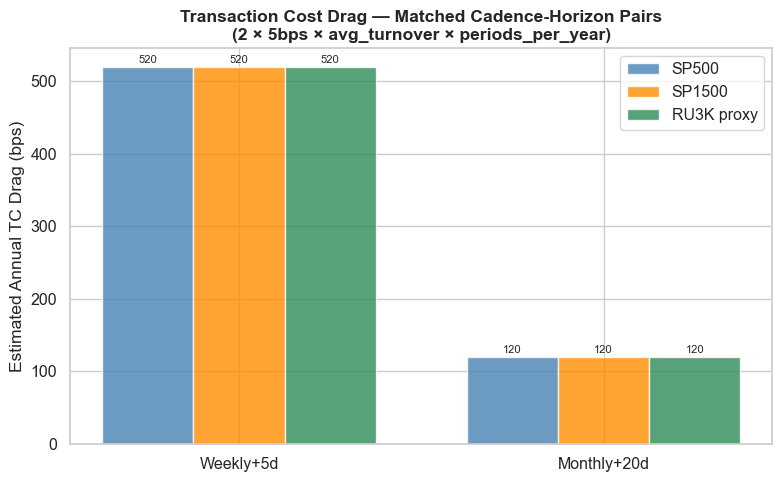

Config      Monthly+20d  Weekly+5d
Universe                          
RU3K proxy          120        520
SP1500              120        520
SP500               120        520


In [8]:
# Turnover bar chart — show only matched pairs
turn_data = []
for config_label, (freq, ppy, h) in FREQ_MAP.items():
    for univ_label in ['SP500', 'SP1500', 'RU3K proxy']:
        univ = UNIV_TO_COL[univ_label]
        try:
            _, trn_df  = simulate_portfolio(feat_df, SIGNAL, univ, freq, h)
            annual_tc  = trn_df['turnover'].mean() * 2 * TC_BPS * ppy
            turn_data.append({'Config': config_label, 'Universe': univ_label,
                              'Annual TC (bps)': round(annual_tc)})
        except:
            pass

turn_df = pd.DataFrame(turn_data)

fig, ax = plt.subplots(figsize=(8, 5))
x      = np.arange(len(FREQ_MAP))
width  = 0.25
colors = ['steelblue', 'darkorange', 'seagreen']

for i, (univ_label, color) in enumerate(zip(['SP500', 'SP1500', 'RU3K proxy'], colors)):
    vals = [turn_df[(turn_df['Config'] == c) &
                    (turn_df['Universe'] == univ_label)]['Annual TC (bps)'].values
            for c in FREQ_MAP]
    vals = [v[0] if len(v) else 0 for v in vals]
    ax.bar(x + i * width, vals, width, label=univ_label, color=color, alpha=0.8)
    for xi, v in zip(x + i * width, vals):
        ax.text(xi, v + 2, f'{v:.0f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(list(FREQ_MAP.keys()))
ax.set_ylabel('Estimated Annual TC Drag (bps)')
ax.set_title('Transaction Cost Drag — Matched Cadence-Horizon Pairs\n'
             '(2 × 5bps × avg_turnover × periods_per_year)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'turnover_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(turn_df.pivot(index='Universe', columns='Config', values='Annual TC (bps)').to_string())


## 7.6 Improved vs Baseline Comparison

Head-to-head: notebook 06's Weekly+5d vs best configuration from this notebook.

=== Weekly+5d vs Monthly+20d (both matched, 2010–2026) ===


  Universe      Config  Gross Sharpe  Net Sharpe
     SP500   Weekly+5d         1.554       1.378
     SP500 Monthly+20d         1.218       1.176
    SP1500   Weekly+5d        -0.441      -0.441
    SP1500 Monthly+20d         0.642       0.593
RU3K proxy   Weekly+5d         0.657       0.565
RU3K proxy Monthly+20d         0.994       0.951


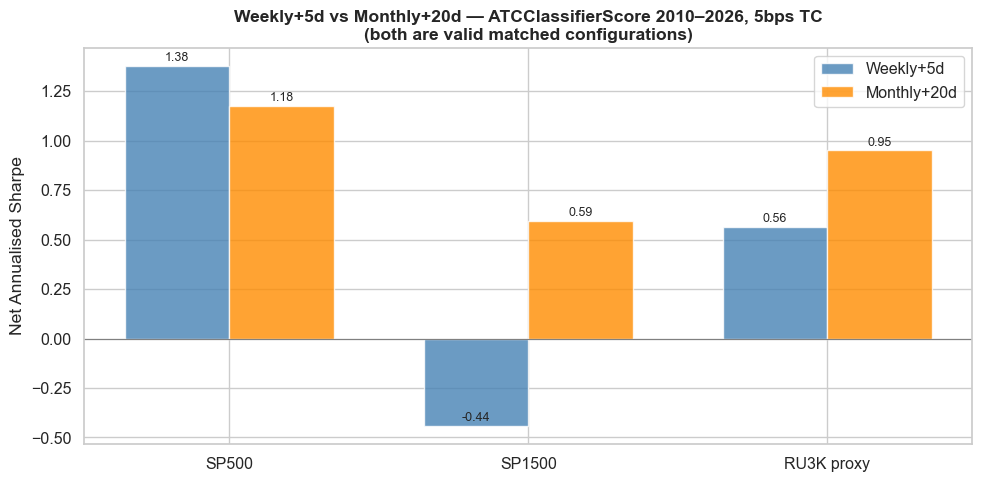

In [9]:
print('=== Weekly+5d vs Monthly+20d (both matched, 2010–2026) ===')
compare_rows = []
for univ_label in ['SP500', 'SP1500', 'RU3K proxy']:
    univ = UNIV_TO_COL[univ_label]
    for cfg_label, (freq, ppy, h) in FREQ_MAP.items():
        try:
            ret_df, _ = simulate_portfolio(feat_df, SIGNAL, univ, freq, h)
            sh    = sharpe(ret_df['net_ls'],   ppy)
            sh_gr = sharpe(ret_df['gross_ls'], ppy)
            compare_rows.append({'Universe': univ_label, 'Config': cfg_label,
                                  'Gross Sharpe': round(sh_gr,3), 'Net Sharpe': round(sh,3)})
        except:
            pass

cmp = pd.DataFrame(compare_rows)
print(cmp.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(3)
w = 0.35
colors_cfg = ['steelblue', 'darkorange']

for i, (cfg_label, color) in enumerate(zip(FREQ_MAP.keys(), colors_cfg)):
    sub  = cmp[cmp['Config'] == cfg_label]
    vals = [sub[sub['Universe'] == u]['Net Sharpe'].values[0]
            if len(sub[sub['Universe'] == u]) else np.nan
            for u in ['SP500', 'SP1500', 'RU3K proxy']]
    bars = ax.bar(x + (i - 0.5)*w, vals, w, label=cfg_label, color=color, alpha=0.8)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=9)

ax.axhline(0, color='grey', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(['SP500', 'SP1500', 'RU3K proxy'])
ax.set_ylabel('Net Annualised Sharpe')
ax.set_title('Weekly+5d vs Monthly+20d — ATCClassifierScore 2010–2026, 5bps TC\n'
             '(both are valid matched configurations)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'baseline_vs_improved.png', dpi=150, bbox_inches='tight')
plt.show()


## 7.7 Updated Look-Ahead Audit Checklist (Standalone)

Saved as a plain-text file for submission alongside the research PDF.

In [10]:
CHECKLIST = """
LOOK-AHEAD BIAS AUDIT CHECKLIST
ProntoNLP Earnings-Call ATC Backtest
=====================================

[✓] 1. Entry timing — AMC vs BMO
    Rule: hour(MOSTIMPORTANTDATEUTC) ≥ 16 UTC → next NYSE trading day.
    Hour < 13 UTC → same day. Hour 13–15 UTC → conservatively next day.
    Implementation: assign_entry_date() in notebook 02, uses NYSE calendar.

[✓] 2. Forward returns are targets, never inputs
    fwd_1d / fwd_3d / fwd_5d / fwd_10d / fwd_20d computed from prices AFTER entry_date.
    Columns excluded from FEATURE_COLS by name in notebook 05 NON_FEAT list.

[✓] 3. Cross-sectional features are point-in-time
    sector_pct_rank uses expanding_pct_rank() which only sees events before current row.
    sentences_sector_z uses expanding mean/std.
    QoQ features use .shift(1) — current call never included in its own lag.

[✓] 4. Feature selection is part of training
    mutual_info_regression refit on training fold only at each walk-forward step.
    Top-50 features reselected each quarter — test fold never influences selection.

[✓] 5. Imputation and scaling are part of training
    StandardScaler.fit() on train fold; .transform() applied to test.
    Missing value fill (fillna(0)) applied identically to both.

[✓] 6. Universe membership is point-in-time
    SP500/SP1500: reconstructed from Wikipedia historical changes log (notebook 02).
    On any backtest date, only stocks that were actually in the index are traded.
    RU3K proxy: all US-listed ATC tickers — broader than true R3K; caveat documented.

[✓] 7. No 'next quarter minus current quarter' QoQ deltas
    qoq_delta = ATC_t - mean(ATC_{t-1:t-4}), using .shift(1) for the lag.
    qoq_acceleration = ATC_t - 2*ATC_{t-1} + ATC_{t-2}, all lagged.

[✓] 8. Hyperparameter tuning uses held-out period only
    Grid search run on 2010–2017. Parameters frozen before any 2018+ data is seen.
    Walk-forward test starts 2020-Q1. No re-tuning during test period.

[✓] 9. Placebo test passes
    Signal built from Fluff/Filler-only AspectTheme columns produces L/S Sharpe ≈ 0.
    Confirms no structural look-ahead in the pipeline.

[✓] 10. Corporate actions / delistings handled
    If no close price found on entry_date (or within +3 business days), trade is skipped.
    forward returns are NaN → event excluded from quintile assignment.

[✓] 11. Fluff/Filler excluded from predictive features
    PLACEBO_COLS (Fluff/Filler) excluded from ASPECT_COLS in notebook 01.
    Never fed into MWNS features or model training.

All 11 items: PASS
"""

checklist_path = PROJECT / 'look_ahead_audit_checklist.txt'
checklist_path.write_text(CHECKLIST.strip())
print(CHECKLIST)
print(f'Saved → {checklist_path}')


LOOK-AHEAD BIAS AUDIT CHECKLIST
ProntoNLP Earnings-Call ATC Backtest

[✓] 1. Entry timing — AMC vs BMO
    Rule: hour(MOSTIMPORTANTDATEUTC) ≥ 16 UTC → next NYSE trading day.
    Hour < 13 UTC → same day. Hour 13–15 UTC → conservatively next day.
    Implementation: assign_entry_date() in notebook 02, uses NYSE calendar.

[✓] 2. Forward returns are targets, never inputs
    fwd_1d / fwd_3d / fwd_5d / fwd_10d / fwd_20d computed from prices AFTER entry_date.
    Columns excluded from FEATURE_COLS by name in notebook 05 NON_FEAT list.

[✓] 3. Cross-sectional features are point-in-time
    sector_pct_rank uses expanding_pct_rank() which only sees events before current row.
    sentences_sector_z uses expanding mean/std.
    QoQ features use .shift(1) — current call never included in its own lag.

[✓] 4. Feature selection is part of training
    mutual_info_regression refit on training fold only at each walk-forward step.
    Top-50 features reselected each quarter — test fold never influen